# 06 — Chemistry-only: Random Forest vs logistic (apples-to-apples)

Matches **`05_soft_vs_good_days_w_SHAP.ipynb`** (not the n=9 microbial RF in Notebook 03).

| | |
|--|--|
| **Why** | Notebook 03 RF is n=9 + 16S. Judges may want an ensemble on the **same >1000-day chemistry task** as logistic. |
| **Y (classifier)** | Soft = `removal_3320_3340` < 95% |
| **Y (regression, optional)** | Continuous `removal_3320_3340` |
| **Split** | Train ≤2016-12-31; test ≥2017 |
| **X** | Same coverage rule as 05 SHAP; exclude `dioxane_3320`, `blend_ratio`, `sed_blend_gap`, all `*_3340` |
| **Outputs** | `data/processed/analysis_results/nb06_*` |


## Step 1 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LogisticRegressionCV, RidgeCV
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "processed").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root()
PROC = PROJECT_ROOT / "data/processed"
CHEM_PATH = PROC / "bts_chemistry_field_by_date.csv"
OUT_DIR = PROC / "analysis_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Y_COL = "removal_3320_3340"
SOFT_THRESHOLD = 95.0
TRAIN_END = "2016-12-31"
MIN_COVERAGE = 0.50
EXCLUDE_FROM_CLF = {"dioxane_3320", "blend_ratio", "sed_blend_gap"}
N_BOOT = 500
RNG = np.random.default_rng(0)

if not CHEM_PATH.exists():
    raise FileNotFoundError(f"Run Notebook 01 first. Missing: {CHEM_PATH}")

print("Project root:", PROJECT_ROOT)
print("Chemistry:", CHEM_PATH)
print(f"Soft: {Y_COL} < {SOFT_THRESHOLD}%")
print("Outputs:", OUT_DIR)

Project root: /Users/shaivikoul/Documents/DIOPredict LOWRY
Chemistry: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/bts_chemistry_field_by_date.csv
Soft: removal_3320_3340 < 95.0%
Outputs: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results


## Step 2 — Load chemistry, same labels / features as 05 SHAP

In [2]:
df = pd.read_csv(CHEM_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
if Y_COL not in df.columns:
    df[Y_COL] = (df["dioxane_3320"] - df["dioxane_3340"]) / df["dioxane_3320"] * 100
df = df.dropna(subset=[Y_COL]).copy()
df["is_soft"] = (df[Y_COL] < SOFT_THRESHOLD).astype(int)
df["blend_ratio"] = df["dioxane_3320"] / df["dioxane_3310"]
df["sed_blend_gap"] = df["dioxane_3310"] - df["dioxane_3320"]

train_mask = df["date"] <= TRAIN_END
test_mask = df["date"] > TRAIN_END

feat_cols = []
for c in df.columns:
    if c in {"date", Y_COL, "is_soft"} or str(c).startswith("removal"):
        continue
    if "_3340" in c:
        continue
    if not (
        str(c).startswith(("pH_", "temp_", "field_", "sr_", "dioxane_"))
        or c in {"blend_ratio", "sed_blend_gap"}
    ):
        continue
    if df[c].dtype == object:
        continue
    if df[c].notna().mean() < MIN_COVERAGE:
        continue
    if df.loc[train_mask, c].notna().mean() < MIN_COVERAGE:
        continue
    feat_cols.append(c)

clf_feats = [c for c in feat_cols if c not in EXCLUDE_FROM_CLF]
print(f"Rows: {len(df)}  train={train_mask.sum()}  test={test_mask.sum()}")
print(f"Soft rate train={df.loc[train_mask,'is_soft'].mean():.1%}  test={df.loc[test_mask,'is_soft'].mean():.1%}")
print(f"Classifier features ({len(clf_feats)}): {clf_feats}")

Xtr = df.loc[train_mask, clf_feats]
Xte = df.loc[test_mask, clf_feats]
ytr = df.loc[train_mask, "is_soft"]
yte = df.loc[test_mask, "is_soft"]

Rows: 1105  train=655  test=450
Soft rate train=22.3%  test=17.8%
Classifier features (15): ['dioxane_3310', 'field_conductivity_3310', 'field_nitrogen_ammonia_3310', 'pH_3310', 'pH_3320', 'temp_3310', 'temp_3320', 'field_total_suspended_solids_3310', 'sr_1_2_dichloroethane_3310', 'sr_1_2_dichloroethane_3320', 'sr_nitrogen_nitrate_plus_nitrite_3310', 'sr_nitrogen_nitrite_3310', 'sr_tetrahydrofuran_3310', 'sr_tetrahydrofuran_3320', 'sr_total_phosphorus_3320']


/var/folders/bp/nw5pdfhs4rsg8kdjvwwcppnm0000gn/T/ipykernel_21553/992313585.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[Y_COL] = (df["dioxane_3320"] - df["dioxane_3340"]) / df["dioxane_3320"] * 100


## Step 3 — Soft-day classifiers: logistic vs Random Forest

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

logistic         AUC=0.758  AUPRC=0.401  bal_acc=0.686


random_forest    AUC=0.816  AUPRC=0.534  bal_acc=0.718
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb06_classifier_comparison.csv

RF top importances:
sr_total_phosphorus_3320                 0.1557
sr_nitrogen_nitrate_plus_nitrite_3310    0.1418
sr_tetrahydrofuran_3320                  0.1379
temp_3320                                0.1318
dioxane_3310                             0.1053
sr_nitrogen_nitrite_3310                 0.0789
sr_1_2_dichloroethane_3310               0.0662
sr_tetrahydrofuran_3310                  0.0350
dtype: float64


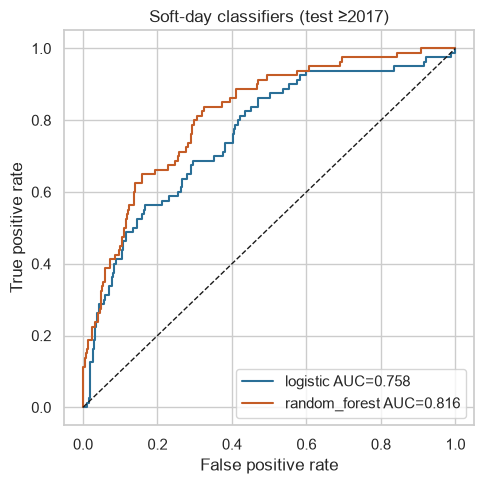

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb06_roc_logistic_vs_rf.png


In [3]:
def clf_metrics(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc_test": roc_auc_score(y_te, proba),
        "auprc_test": average_precision_score(y_te, proba),
        "balanced_acc_test": balanced_accuracy_score(y_te, pred),
        "n_train": len(y_tr),
        "n_test": len(y_te),
        "soft_rate_test": float(y_te.mean()),
        "pipe": pipe,
        "proba": proba,
    }


logit = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        (
            "clf",
            LogisticRegressionCV(
                Cs=10,
                cv=5,
                max_iter=3000,
                class_weight="balanced",
                scoring="roc_auc",
            ),
        ),
    ]
)
rf = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=15,
                class_weight="balanced",
                random_state=0,
                n_jobs=-1,
            ),
        ),
    ]
)

rows = []
fitted = {}
for name, model in [("logistic", logit), ("random_forest", rf)]:
    out = clf_metrics(name, model, Xtr, ytr, Xte, yte)
    fitted[name] = out
    rows.append({k: v for k, v in out.items() if k not in {"pipe", "proba"}})
    print(
        f"{name:15s}  AUC={out['roc_auc_test']:.3f}  AUPRC={out['auprc_test']:.3f}  "
        f"bal_acc={out['balanced_acc_test']:.3f}"
    )

cmp = pd.DataFrame(rows)
cmp_path = OUT_DIR / "nb06_classifier_comparison.csv"
cmp.to_csv(cmp_path, index=False)
print("Saved:", cmp_path)

imp = pd.Series(
    fitted["random_forest"]["pipe"].named_steps["clf"].feature_importances_,
    index=clf_feats,
).sort_values(ascending=False)
imp.to_csv(OUT_DIR / "nb06_rf_feature_importances.csv", header=["importance"])
print("\nRF top importances:")
print(imp.head(8).round(4))

fig, ax = plt.subplots(figsize=(5, 5))
for name, color in [("logistic", "#2a6f97"), ("random_forest", "#c45c26")]:
    fpr, tpr, _ = roc_curve(yte, fitted[name]["proba"])
    ax.plot(fpr, tpr, color=color, label=f"{name} AUC={fitted[name]['roc_auc_test']:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Soft-day classifiers (test ≥2017)")
ax.legend()
fig.tight_layout()
p_roc = OUT_DIR / "nb06_roc_logistic_vs_rf.png"
fig.savefig(p_roc, dpi=150)
plt.show()
print("Saved:", p_roc)

## Step 4 — Bootstrap 95% CIs (logistic coefs + test AUC)

Resample **training days** with replacement, refit, score the **fixed** 2017+ test set.  
This is a CI, not SHAP threshold-stability.

In [4]:
def make_logit():
    return Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegressionCV(
                    Cs=8,
                    cv=3,
                    max_iter=2000,
                    class_weight="balanced",
                    scoring="roc_auc",
                ),
            ),
        ]
    )


def make_rf():
    return Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=6,
                    min_samples_leaf=15,
                    class_weight="balanced",
                    random_state=0,
                    n_jobs=-1,
                ),
            ),
        ]
    )


key_feats = [
    c
    for c in [
        "sr_total_phosphorus_3320",
        "temp_3320",
        "sr_nitrogen_nitrate_plus_nitrite_3310",
        "field_nitrogen_ammonia_3310",
        "sr_tetrahydrofuran_3320",
    ]
    if c in clf_feats
]

boot_auc_logit, boot_auc_rf = [], []
boot_coef = {f: [] for f in key_feats}
idx = np.arange(len(Xtr))

for b in range(N_BOOT):
    take = RNG.choice(idx, size=len(idx), replace=True)
    Xb, yb = Xtr.iloc[take], ytr.iloc[take]
    if yb.nunique() < 2:
        continue
    pl = make_logit()
    pl.fit(Xb, yb)
    boot_auc_logit.append(roc_auc_score(yte, pl.predict_proba(Xte)[:, 1]))
    coefs = pd.Series(pl.named_steps["clf"].coef_[0], index=clf_feats)
    for f in key_feats:
        boot_coef[f].append(coefs[f])
    pr = make_rf()
    pr.fit(Xb, yb)
    boot_auc_rf.append(roc_auc_score(yte, pr.predict_proba(Xte)[:, 1]))
    if (b + 1) % 100 == 0:
        print(f"bootstrap {b+1}/{N_BOOT}")


def ci95(a):
    a = np.asarray(a, dtype=float)
    return float(np.nanpercentile(a, 2.5)), float(np.nanpercentile(a, 97.5)), float(np.nanmean(a))


ci_rows = []
lo, hi, mu = ci95(boot_auc_logit)
ci_rows.append({"quantity": "logistic_test_AUC", "mean": mu, "ci95_low": lo, "ci95_high": hi})
lo, hi, mu = ci95(boot_auc_rf)
ci_rows.append({"quantity": "rf_test_AUC", "mean": mu, "ci95_low": lo, "ci95_high": hi})
for f in key_feats:
    lo, hi, mu = ci95(boot_coef[f])
    ci_rows.append(
        {
            "quantity": f"logit_coef_{f}",
            "mean": mu,
            "ci95_low": lo,
            "ci95_high": hi,
            "excludes_zero": int(lo * hi > 0),
        }
    )
ci_df = pd.DataFrame(ci_rows)
ci_path = OUT_DIR / "nb06_bootstrap_ci.csv"
ci_df.to_csv(ci_path, index=False)
print("\nBootstrap 95% CIs (train resample, fixed test):")
print(ci_df.round(4).to_string(index=False))
print("Saved:", ci_path)

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

...

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

bootstrap 500/500

Bootstrap 95% CIs (train resample, fixed test):
                                        quantity    mean  ci95_low  ci95_high  excludes_zero
                               logistic_test_AUC  0.7445    0.6170     0.7984            NaN
                                     rf_test_AUC  0.8048    0.7596     0.8397            NaN
             logit_coef_sr_total_phosphorus_3320 -0.4168   -1.2044    -0.0275            1.0
                            logit_coef_temp_3320 -0.5569   -0.9706    -0.2367            1.0
logit_coef_sr_nitrogen_nitrate_plus_nitrite_3310 -0.6511   -1.7519    -0.1968            1.0
          logit_coef_field_nitrogen_ammonia_3310  0.1250   -0.1691     0.4914            0.0
              logit_coef_sr_tetrahydrofuran_3320 -0.2591   -0.6477    -0.0006            1.0
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb06_bootstrap_ci.csv


## Step 5 — Optional: continuous % regression (Ridge / LASSO / RF)

Same X and time split as the classifier. Completes apples-to-apples vs Notebook 04/04b (linear only).

In [5]:
ytr_r = df.loc[train_mask, Y_COL]
yte_r = df.loc[test_mask, Y_COL]

reg_specs = {
    "ridge": Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", RidgeCV(alphas=np.logspace(-2, 3, 20))),
        ]
    ),
    "lasso": Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            ("m", LassoCV(cv=5, max_iter=5000, random_state=0)),
        ]
    ),
    "random_forest": Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            (
                "m",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=6,
                    min_samples_leaf=15,
                    random_state=0,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

reg_rows = []
for name, pipe in reg_specs.items():
    pipe.fit(Xtr, ytr_r)
    pred_tr, pred_te = pipe.predict(Xtr), pipe.predict(Xte)
    row = {
        "model": name,
        "r2_train": r2_score(ytr_r, pred_tr),
        "r2_test": r2_score(yte_r, pred_te),
    }
    reg_rows.append(row)
    print(f"{name:15s}  R2_train={row['r2_train']:.3f}  R2_test={row['r2_test']:.3f}")

reg_df = pd.DataFrame(reg_rows)
reg_path = OUT_DIR / "nb06_regression_comparison.csv"
reg_df.to_csv(reg_path, index=False)
print("Saved:", reg_path)

ridge            R2_train=0.164  R2_test=0.029
lasso            R2_train=0.132  R2_test=-0.006


random_forest    R2_train=0.311  R2_test=0.130
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb06_regression_comparison.csv


## Step 5b — TreeExplainer SHAP on the chemistry RF (same test set as Notebook 05)

Explain the **fitted RF classifier** from Step 3 on imputed 2017+ test days.  
This is **not** Gini importance and **not** logistic LinearExplainer. No threshold sweep, no interactions, no extra bootstrap.

RF TreeSHAP mean |SHAP| (test ≥2017):
sr_total_phosphorus_3320                 0.0943
dioxane_3310                             0.0526
temp_3320                                0.0444
sr_tetrahydrofuran_3320                  0.0444
sr_nitrogen_nitrate_plus_nitrite_3310    0.0439
sr_nitrogen_nitrite_3310                 0.0242
sr_1_2_dichloroethane_3320               0.0165
sr_1_2_dichloroethane_3310               0.0136
sr_tetrahydrofuran_3310                  0.0122
field_conductivity_3310                  0.0114
field_total_suspended_solids_3310        0.0092
field_nitrogen_ammonia_3310              0.0082
pH_3320                                  0.0079
pH_3310                                  0.0031
temp_3310                                0.0016
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb06_rf_shap_mean_abs.csv

Logistic SHAP top-5 (Notebook 05, 95%):
  1. sr_total_phosphorus_3320
  2. sr_nitrogen_nitrate_plus_nitrite_3310
  3. field_conduct

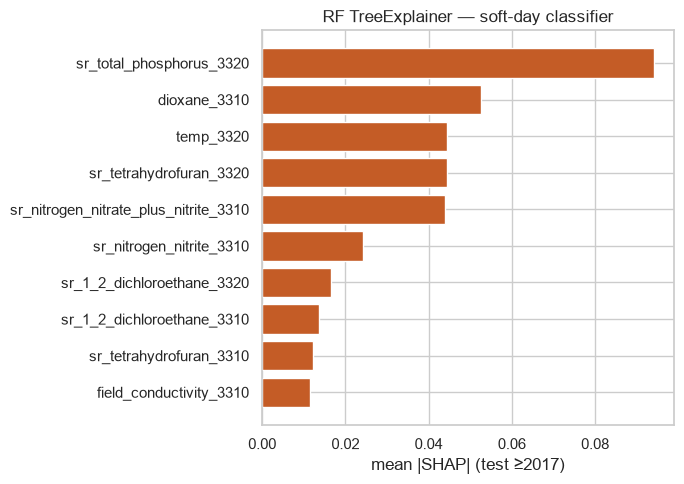

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb06_rf_shap_bar.png


In [6]:
import shap

# Logistic LinearExplainer top-5 at 95% from Notebook 05 (test ≥2017)
LOGIT_SHAP_TOP5 = [
    "sr_total_phosphorus_3320",
    "sr_nitrogen_nitrate_plus_nitrite_3310",
    "field_conductivity_3310",
    "dioxane_3310",
    "field_total_suspended_solids_3310",
]

rf_pipe = fitted["random_forest"]["pipe"]
imp_rf = rf_pipe.named_steps["imp"]
rf_clf = rf_pipe.named_steps["clf"]
Xtr_i = imp_rf.transform(Xtr)
Xte_i = imp_rf.transform(Xte)

explainer = shap.TreeExplainer(rf_clf)
sv = explainer.shap_values(Xte_i)
if isinstance(sv, list):
    values = np.asarray(sv[1] if len(sv) > 1 else sv[0])
else:
    values = np.asarray(sv.values if hasattr(sv, "values") else sv)
    if values.ndim == 3:
        values = values[:, :, 1]

mean_abs_rf = pd.Series(np.abs(values).mean(axis=0), index=clf_feats).sort_values(ascending=False)
shap_path = OUT_DIR / "nb06_rf_shap_mean_abs.csv"
mean_abs_rf.to_csv(shap_path, header=["mean_abs_shap"])
print("RF TreeSHAP mean |SHAP| (test ≥2017):")
print(mean_abs_rf.round(4).to_string())
print("Saved:", shap_path)

rf_top5 = list(mean_abs_rf.head(5).index)
overlap = [f for f in rf_top5 if f in LOGIT_SHAP_TOP5]
print("\nLogistic SHAP top-5 (Notebook 05, 95%):")
for i, f in enumerate(LOGIT_SHAP_TOP5, 1):
    print(f"  {i}. {f}")
print("RF TreeSHAP top-5:")
for i, f in enumerate(rf_top5, 1):
    print(f"  {i}. {f}")
print(f"Overlap: {len(overlap)}/5 — {overlap}")
print(
    "Phosphorus 3320 RF rank:",
    int(mean_abs_rf.index.get_loc("sr_total_phosphorus_3320")) + 1
    if "sr_total_phosphorus_3320" in mean_abs_rf.index
    else "not in features",
)

cmp_shap = pd.DataFrame(
    {
        "rank": range(1, 6),
        "logistic_shap_05": LOGIT_SHAP_TOP5,
        "rf_treeshap_06": rf_top5,
    }
)
cmp_shap_path = OUT_DIR / "nb06_shap_top5_compare.csv"
cmp_shap.to_csv(cmp_shap_path, index=False)
print("Saved:", cmp_shap_path)

fig, ax = plt.subplots(figsize=(7, 5))
plot_s = mean_abs_rf.head(10).sort_values(ascending=True)
ax.barh(plot_s.index.astype(str), plot_s.values, color="#c45c26")
ax.set_xlabel("mean |SHAP| (test ≥2017)")
ax.set_title("RF TreeExplainer — soft-day classifier")
fig.tight_layout()
p_bar = OUT_DIR / "nb06_rf_shap_bar.png"
fig.savefig(p_bar, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p_bar)

## Step 6 — Takeaways

In [7]:
lines = []
lines.append("NB06 VERDICT — Chemistry RF vs logistic (same task as 05 SHAP)")
lines.append("=" * 70)
lines.append("NOT the n=9 microbial RF (Notebook 03).")
lines.append("")
lines.append("Soft-day classification (test ≥2017):")
for _, r in cmp.iterrows():
    lines.append(
        f"  {r['model']}: AUC={r['roc_auc_test']:.3f}  AUPRC={r['auprc_test']:.3f}  "
        f"bal_acc={r['balanced_acc_test']:.3f}"
    )
lines.append("")
lines.append("Bootstrap 95% CI (train resample, fixed test):")
for _, r in ci_df.iterrows():
    extra = ""
    if "excludes_zero" in r and pd.notna(r.get("excludes_zero")):
        extra = f"  excludes0={bool(r['excludes_zero'])}"
    lines.append(
        f"  {r['quantity']}: {r['mean']:.4f}  [{r['ci95_low']:.4f}, {r['ci95_high']:.4f}]{extra}"
    )
lines.append("")
lines.append("Continuous Y3320 regression (same X/split):")
for _, r in reg_df.iterrows():
    lines.append(f"  {r['model']}: R2_train={r['r2_train']:.3f}  R2_test={r['r2_test']:.3f}")
lines.append("")
lines.append("RF vs logistic SHAP (mean |SHAP| test ≥2017):")
lines.append("  logistic top-5: " + ", ".join(LOGIT_SHAP_TOP5))
lines.append("  RF TreeSHAP top-5: " + ", ".join(rf_top5))
lines.append(f"  overlap: {len(overlap)}/5")
if "sr_total_phosphorus_3320" in mean_abs_rf.index:
    lines.append(
        f"  phosphorus_3320 RF rank: {int(mean_abs_rf.index.get_loc('sr_total_phosphorus_3320')) + 1}"
    )
lines.append("")
lines.append("Paper use: comparison table + CIs + RF TreeSHAP vs logistic SHAP.")
verdict = "\n".join(lines)
(OUT_DIR / "nb06_VERDICT.txt").write_text(verdict)
print(verdict)
print("\nSaved:", OUT_DIR / "nb06_VERDICT.txt")

NB06 VERDICT — Chemistry RF vs logistic (same task as 05 SHAP)
NOT the n=9 microbial RF (Notebook 03).

Soft-day classification (test ≥2017):
  logistic: AUC=0.758  AUPRC=0.401  bal_acc=0.686
  random_forest: AUC=0.816  AUPRC=0.534  bal_acc=0.718

Bootstrap 95% CI (train resample, fixed test):
  logistic_test_AUC: 0.7445  [0.6170, 0.7984]
  rf_test_AUC: 0.8048  [0.7596, 0.8397]
  logit_coef_sr_total_phosphorus_3320: -0.4168  [-1.2044, -0.0275]  excludes0=True
  logit_coef_temp_3320: -0.5569  [-0.9706, -0.2367]  excludes0=True
  logit_coef_sr_nitrogen_nitrate_plus_nitrite_3310: -0.6511  [-1.7519, -0.1968]  excludes0=True
  logit_coef_field_nitrogen_ammonia_3310: 0.1250  [-0.1691, 0.4914]  excludes0=False
  logit_coef_sr_tetrahydrofuran_3320: -0.2591  [-0.6477, -0.0006]  excludes0=True

Continuous Y3320 regression (same X/split):
  ridge: R2_train=0.164  R2_test=0.029
  lasso: R2_train=0.132  R2_test=-0.006
  random_forest: R2_train=0.311  R2_test=0.130

RF vs logistic SHAP (mean |SHAP| 